### Задание.

В файле *immunology_dataset.csv* представлены иммунологические данные для трех групп людей (переменная Group):

- Здоровые (Healthy)  
- Пациенты с аутоиммунным заболеванием (Autoimmune)  
- Пациенты с  онкологическим заболеванием (Cancer)  

Для каждого пациента измерены следующие показатели:  
- Пол (Gender) — категориальная переменная (M/F)  
- Возраст (Age) — количественная переменная (годы)  
- Индекс массы тела (BMI) — количественная переменная  
- Уровень экспрессии гена IL6 (IL6_expression) — количественная переменная  
- Уровень экспрессии гена TNFα (TNF_expression) — количественная переменная  
- Уровень С-реактивного белка (CRP) — количественная переменная (мг/л)  
- Количество лейкоцитов (WBC) — количественная переменная (тыс/мкл)  
- Наличие аутоантител (Autoantibodies) — бинарная переменная  

Ответьте на следующие вопросы и выполните задания на основе представленного датасета:

1) Проверьте все количественные переменные на нормальность. Постройте для каждой рассматриваемой переменной PDF (на одном рисунке).

2) Постройте диаграммы рассеяния между переменными IL6 и TNFα, а также между переменными BMI и Age. На каждой из них раскрасьте точки разными цветами в зависимости от группы. Наблюдается ли взаимосвязь в парах указанных переменных (пока просто предположите на основе графиков)?

3) Постройте тепловую карту матрицы корреляций для всех количественных переменных. Выпишите пары переменных, для которых наблюдается положительная корреляция или отрицательная корреляция.

4) Наблюдается ли статистически значимая корреляция между уровнями экспрессии IL6 и TNFα в общем случае (рассмотреть всех людей)? Различается ли эта корреляция по группам?

5) Отличается ли уровень экспрессии IL6 между здоровыми и онкологическими пациентами?

6) Отличается ли возраст между тремя группами?

7) Наблюдается ли более высокий уровень CRP в группе аутоимунных заболеваний по сравнению со здоровой группой?

8) Наблюдается ли связь между группой и наличием аутоантител?

9) Наблюдается ли связь между полом и наличием аутоантител в группе аутоимунных заболеваний?

10) Какие из переменных (Age, BMI, IL6_expression, TNF_expression, CRP и WBC) статистически значимо отличаются между группой аутоимунных заболеваний и онкологической группой?

## 1. Загрузка данных и подготовка


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

file_path = 'immunology_dataset.csv'
df = pd.read_csv(file_path)
df.head()

,Group,Gender,Age,BMI,IL6_expression,TNF_expression,CRP,WBC,Autoantibodies
0,Cancer,M,52,24.3,14.55,2.30,4.7,10.4,1
1,Autoimmune,F,21,22.6,10.75,18.85,20.1,8.1,1
2,Healthy,F,42,24.8,2.24,3.12,0.2,6.6,0
3,Cancer,M,60,21.8,8.15,7.04,4.3,13.4,0
4,Cancer,F,49,28.4,13.86,3.78,0.1,5.5,0


## 2. Проверка количественных переменных на нормальность и построение PDF

,stat,p-value
Age,0.988401,5.382106e-01
BMI,0.994653,9.651500e-01
IL6_expression,0.914121,6.955900e-06
TNF_expression,0.916599,9.332324e-06
CRP,0.645249,3.392532e-14
WBC,0.981654,1.784897e-01


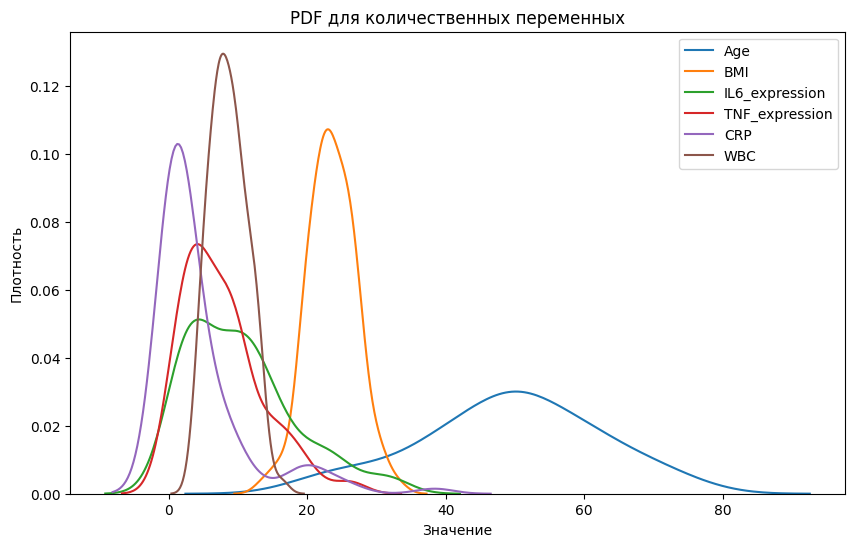

In [21]:
# Количественные переменные
num_cols = ['Age', 'BMI', 'IL6_expression', 'TNF_expression', 'CRP', 'WBC']

# Проверка на нормальность (тест Шапиро-Уилка), почему он
norm_results = {col: stats.shapiro(df[col]) for col in num_cols}
display(pd.DataFrame({k: {'stat': v.statistic, 'p-value': v.pvalue} for k, v in norm_results.items()}).T)

# PDF для всех количественных переменных
plt.figure(figsize=(10, 6))
for col in num_cols:
    sns.kdeplot(df[col], label=col)
plt.xlabel('Значение')
plt.ylabel('Плотность')
plt.title('PDF для количественных переменных')
plt.legend()
plt.show()


## 3. Диаграммы рассеяния между IL6 и TNFα, а также между BMI и Age

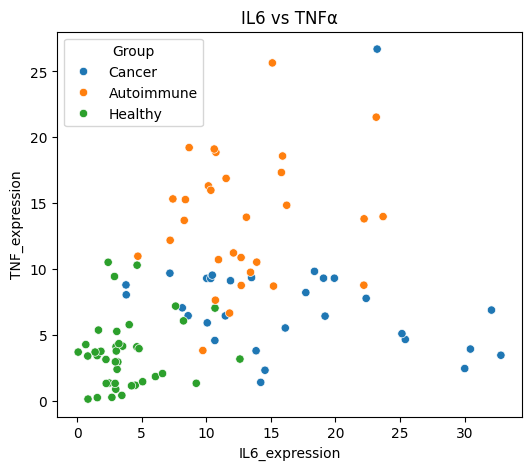

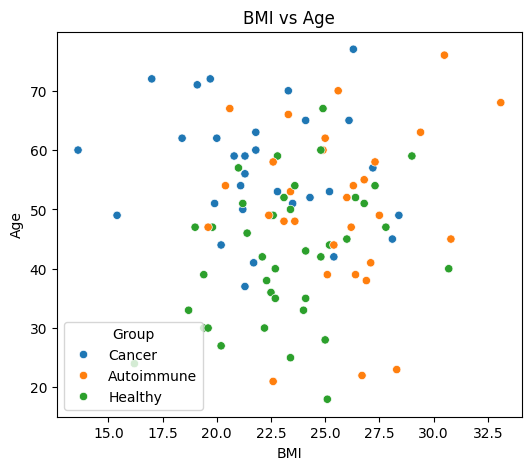

In [22]:
# Диаграмма рассеяния IL6 и TNFα
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='IL6_expression', y='TNF_expression', hue='Group')
plt.title('IL6 vs TNFα')
plt.show()

# Диаграмма рассеяния BMI и Age
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='BMI', y='Age', hue='Group')
plt.title('BMI vs Age')
plt.show()

Взаимосвязь не наблюдается


## 4. Тепловая карта корреляций количественных переменных

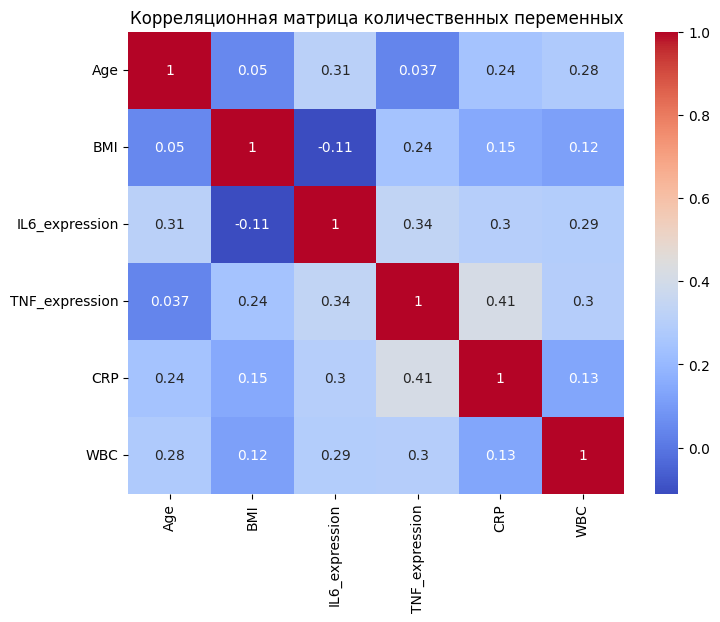

Положительная корреляция:
Отрицательная корреляция:


In [23]:
# Корреляционная матрица
corr = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица количественных переменных')
plt.show()

# Пары с положительной и отрицательной корреляцией
corr = df[num_cols].corr()
corr_pairs = corr.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
strong_pos = corr_pairs[corr_pairs > 0.5]
strong_neg = corr_pairs[corr_pairs < -0.5]
print('Положительная корреляция:')
for idx, val in strong_pos.items():
    display(f'{idx[0]} и {idx[1]}: {val:.2f}')
print('Отрицательная корреляция:')
for idx, val in strong_neg.items():
    display(f'{idx[0]} и {idx[1]}: {val:.2f}')

## 5. Корреляция между IL6 и TNFα (общая и по группам)

In [24]:
# Общая корреляция p val добавить
corr_all = df['IL6_expression'].corr(df['TNF_expression'])
print(f'Корреляция между IL6 и TNFα: {corr_all:.2f}')
# Корреляция по группам
group_corr = df.groupby('Group')[['IL6_expression', 'TNF_expression']].corr().iloc[0::2,-1].reset_index()
group_corr

Корреляция между IL6 и TNFα: 0.34


,Group,level_1,TNF_expression
0,Autoimmune,IL6_expression,0.134049
1,Cancer,IL6_expression,-0.102764
2,Healthy,IL6_expression,0.136997


Корреляция маленькая

## 6. Сравнение IL6 между здоровыми и онкологическими пациентами

In [ ]:
# сначала проверяем нормальность распределения, потом сравниваем между группами, если не нормальное распределение, то используем непараметрические тесты, если нормальное то t test
# Сравнение IL6 между Healthy и Cancer
healthy = df[df['Group'] == 'Healthy']['IL6_expression']
cancer = df[df['Group'] == 'Cancer']['IL6_expression']
# Тест Манна-Уитни (непараметрический)
stats.mannwhitneyu(healthy, cancer)

MannwhitneyuResult(statistic=np.float64(52.0), pvalue=np.float64(8.159540554362872e-11))

Результат теста Манна-Уитни показывает, есть ли статистически значимая разница в уровне IL6 между здоровыми и онкологическими пациентами. p-value очень маленькое, значит различие действительно есть.

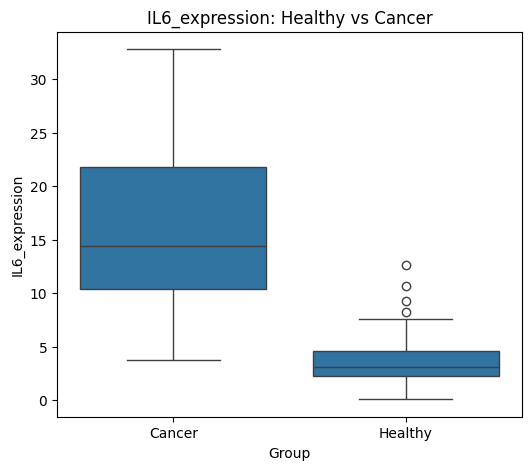

In [26]:
# Визуализация: boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(data=df[df['Group'].isin(['Healthy', 'Cancer'])], x='Group', y='IL6_expression')
plt.title('IL6_expression: Healthy vs Cancer')
plt.show()

## 7. Сравнение возраста между тремя группами

In [27]:
# Сравнение возраста между группами 
groups = [df[df['Group'] == g]['Age'] for g in df['Group'].unique()]
stats.kruskal(*groups)

KruskalResult(statistic=np.float64(20.783082096544565), pvalue=np.float64(3.069100177049137e-05))

p-value маленькое, значит различие действительно есть

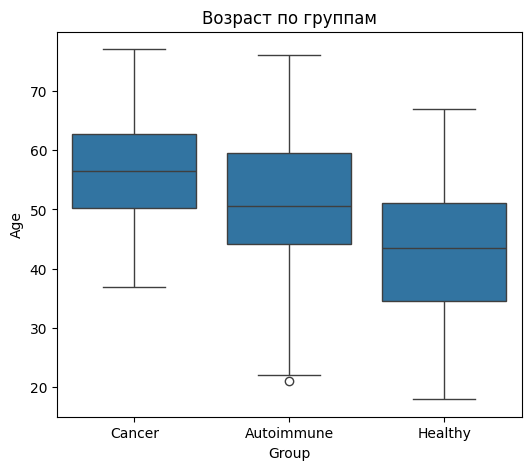

In [28]:
# Визуализация: boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='Group', y='Age')
plt.title('Возраст по группам')
plt.show()

## 8. Сравнение CRP между Autoimmune и Healthy

In [29]:
# Сравнение CRP между Autoimmune и Healthy
auto = df[df['Group'] == 'Autoimmune']['CRP']
healthy = df[df['Group'] == 'Healthy']['CRP']
stats.mannwhitneyu(auto, healthy, alternative='greater')

MannwhitneyuResult(statistic=np.float64(1069.0), pvalue=np.float64(1.3115611464127392e-08))

p-value очень маленькое, значит различие действительно есть

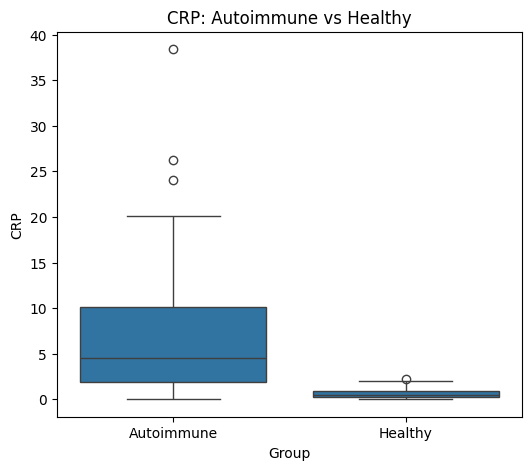

In [30]:
# Визуализация: boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(data=df[df['Group'].isin(['Autoimmune', 'Healthy'])], x='Group', y='CRP')
plt.title('CRP: Autoimmune vs Healthy')
plt.show()

## 9. Связь между группой и наличием аутоантител

In [31]:
from scipy.stats import chi2_contingency

# Таблица сопряжённости
tab = pd.crosstab(df['Group'], df['Autoantibodies'])

# Тест хи-квадрат
chi2, p, dof, _ = chi2_contingency(tab)

# Красивый вывод
print("Таблица сопряжённости:")
print(tab)
print(f"\nχ² = {chi2:.3f}, p = {p:.4f} {'(p < 0.05)' if p < 0.05 else '(p ≥ 0.05)'}")

Таблица сопряжённости:
Autoantibodies   0   1
Group                 
Autoimmune       7  23
Cancer          23   7
Healthy         33   7

χ² = 29.179, p = 0.0000 (p < 0.05)


сильная, достоверная связь между группой и аутоантителами.

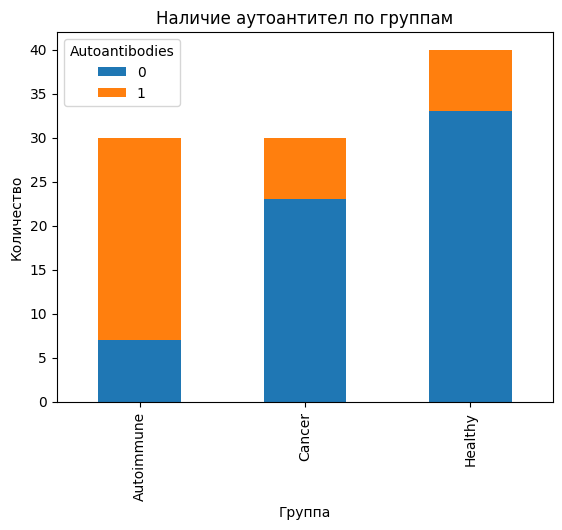

In [32]:
# Визуализация: barplot
tab = pd.crosstab(df['Group'], df['Autoantibodies'])
tab.plot(kind='bar', stacked=True)
plt.title('Наличие аутоантител по группам')
plt.xlabel('Группа')
plt.ylabel('Количество')
plt.show()

## 10. Связь между полом и аутоантителами в группе аутоиммунных заболеваний

In [37]:
auto = df[df['Group'] == 'Autoimmune']
# Таблица сопряжённости: Пол vs Аутоантитела
tab = pd.crosstab(auto['Gender'], auto['Autoantibodies'])
# Критерий хи-квадрат
chi2, p, dof, _ = chi2_contingency(tab)
print(tab)
print(f"\nχ² = {chi2:.3f}, p = {p:.4f} {'(p < 0.05)' if p < 0.05 else '(p ≥ 0.05)'}")


Autoantibodies  0   1
Gender               
F               7  15
M               0   8

χ² = 1.780, p = 0.1822 (p ≥ 0.05)


Критерий хи-квадрат проверяет, связаны ли пол и наличие аутоантител в группе аутоиммунных заболеваний. Если p-value маленькое, значит связь есть.

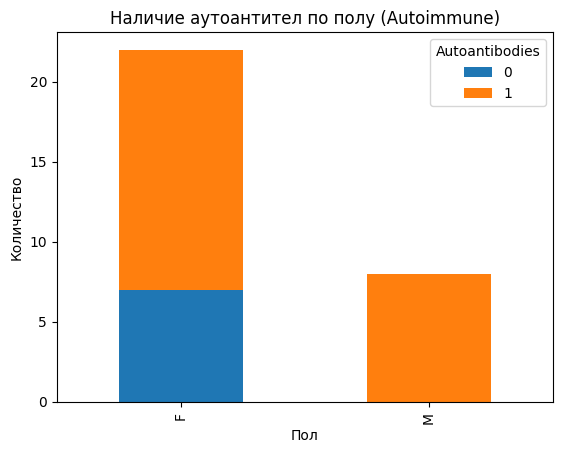

In [34]:
# Визуализация: barplot
auto = df[df['Group'] == 'Autoimmune']
tab = pd.crosstab(auto['Gender'], auto['Autoantibodies'])
tab.plot(kind='bar', stacked=True)
plt.title('Наличие аутоантител по полу (Autoimmune)')
plt.xlabel('Пол')
plt.ylabel('Количество')
plt.show()

## 11. Какие переменные статистически значимо отличаются между Autoimmune и Cancer

In [ ]:
# Сравнение переменных между Autoimmune и Cancer + коррекция нужна
auto = df[df['Group'] == 'Autoimmune']
cancer = df[df['Group'] == 'Cancer']
vars_to_check = ['Age', 'BMI', 'IL6_expression', 'TNF_expression', 'CRP', 'WBC']
results = {}
for var in vars_to_check:
    results[var] = stats.mannwhitneyu(auto[var], cancer[var])
results

{'Age': MannwhitneyuResult(statistic=np.float64(332.0), pvalue=np.float64(0.08218682560959992)),
 'BMI': MannwhitneyuResult(statistic=np.float64(692.5), pvalue=np.float64(0.0003458649513878723)),
 'IL6_expression': MannwhitneyuResult(statistic=np.float64(348.0), pvalue=np.float64(0.13345408758779304)),
 'TNF_expression': MannwhitneyuResult(statistic=np.float64(787.0), pvalue=np.float64(6.523811813545671e-07)),
 'CRP': MannwhitneyuResult(statistic=np.float64(547.0), pvalue=np.float64(0.1535471902640417)),
 'WBC': MannwhitneyuResult(statistic=np.float64(442.0), pvalue=np.float64(0.9116820881479285))}

#### Вывод по пункту 10

Сравнение между группой аутоиммунных заболеваний и онкологической группой:
- Статистически значимые различия (p-value < 0.05) обнаружены для BMI (p = 0.0003) и TNF_expression (p ≈ 6.5e-7).
- Для остальных переменных (Age, IL6_expression, CRP, WBC) различия не являются статистически значимыми (p-value > 0.05).

**Вывод:** между группами значимо отличаются только BMI и экспрессия TNFα.